# Message Count Over Time

Visualization of message counts per date from the Usenet archive.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

In [2]:
df = pd.read_csv("../data/date_count.csv")
num_messages_with_unknown_date = df[df.date == "unknown"]["count"].item()
print(f"Number of messages with unknown date: {num_messages_with_unknown_date}")

df = df[df["date"] != "unknown"]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.head()

Number of messages with unknown date: 3395


,date,count
6851,1991-01-23,1
6815,1992-04-04,3
6858,1992-05-09,1
6315,1992-07-20,3
6316,1992-07-25,4


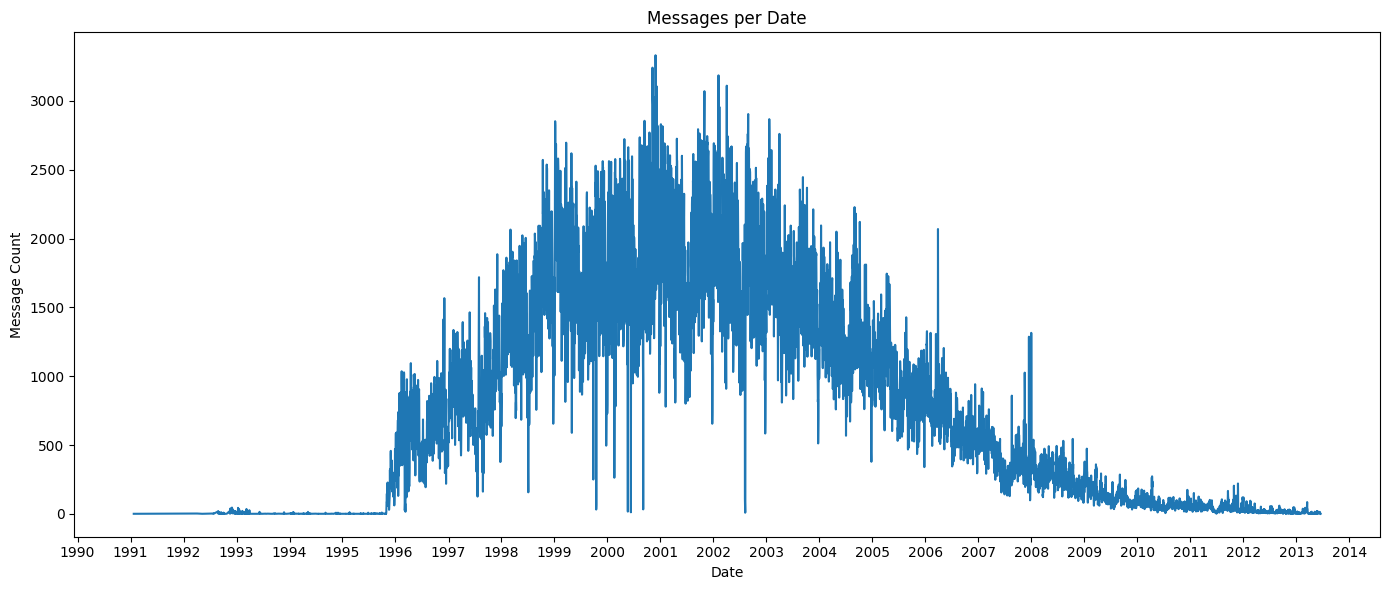

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["date"], df["count"])
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")
ax.set_ylabel("Message Count")
ax.set_title("Messages per Date")
plt.tight_layout()
plt.show()

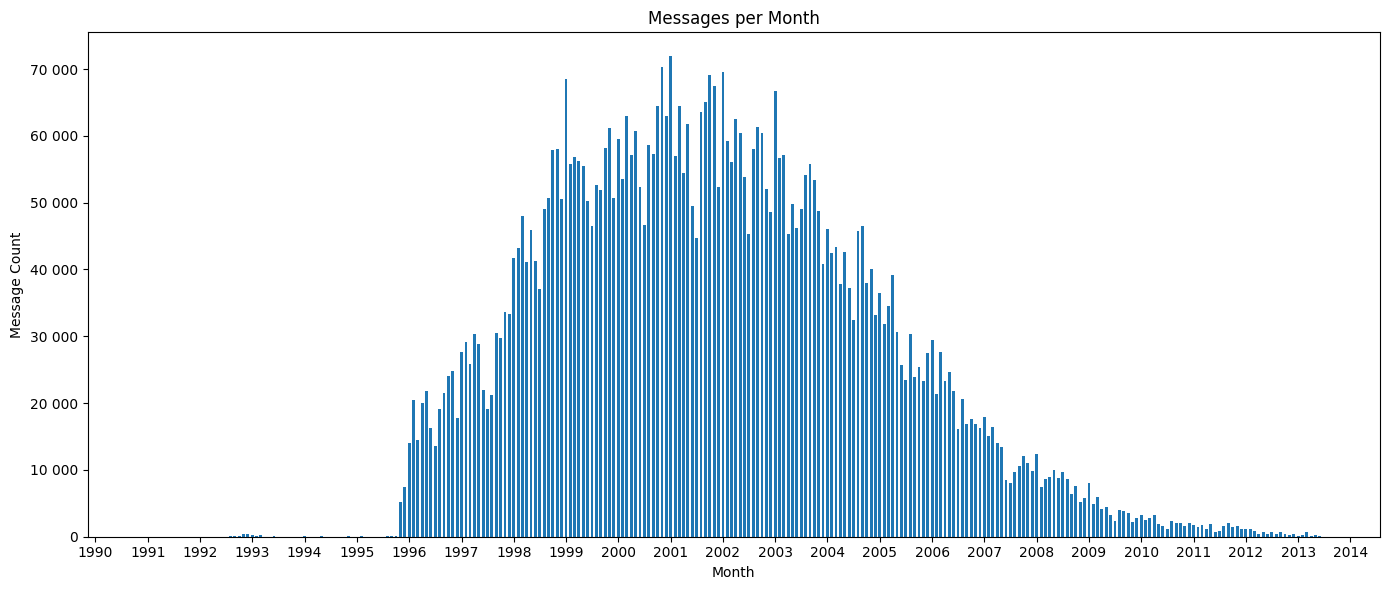

In [4]:
# Monthly aggregation
df["month"] = df["date"].dt.to_period("M")
monthly = df.groupby("month")["count"].sum().reset_index()
monthly["month"] = monthly["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(monthly["month"], monthly["count"], width=20)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))
)
ax.set_xlabel("Month")
ax.set_ylabel("Message Count")
ax.set_title("Messages per Month")
plt.tight_layout()
plt.show()

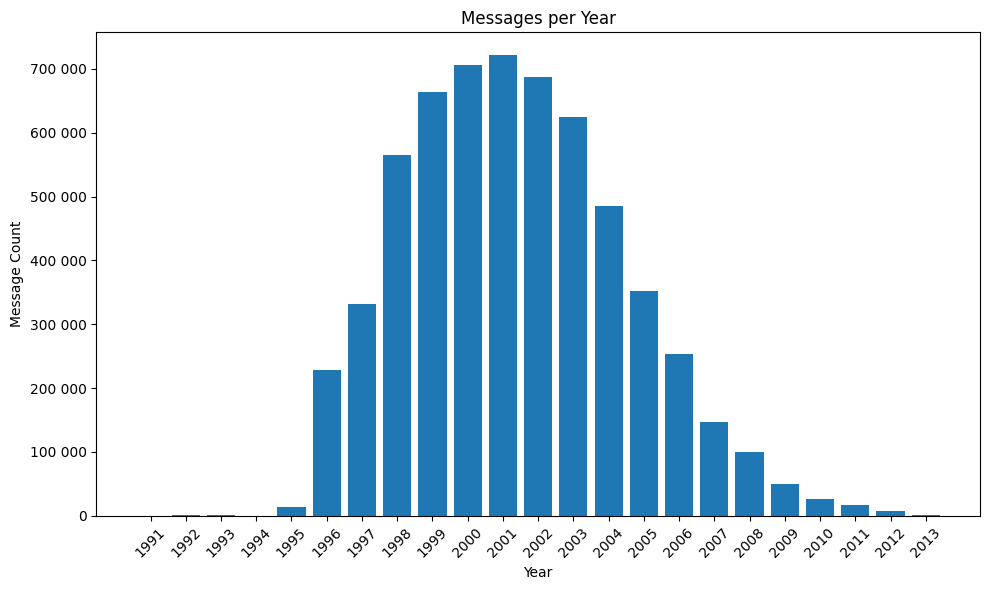

In [5]:
# Yearly aggregation
df["year"] = df["date"].dt.year
yearly = df.groupby("year")["count"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(yearly["year"], yearly["count"])
ax.set_xticks(yearly["year"])
ax.set_xticklabels(yearly["year"], rotation=45)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))
)
ax.set_xlabel("Year")
ax.set_ylabel("Message Count")
ax.set_title("Messages per Year")
plt.tight_layout()
plt.show()